# Data Preprocessing

## 1. Load Dataset

This notebook performs preprocessing activities required for the customer churn dataset. The activities include duplicate checking, missing value analysis, blank value handling, data type conversion, imputation, encoding, binning, normalization, and saving the processed dataset for machine learning.

In [20]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler

print("Libraries imported successfully.")

Libraries imported successfully.


In [21]:
df = pd.read_csv("../data/raw/customer_churn.csv")

print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Duplicate Record Check

Duplicate records can negatively affect the performance of machine learning models. Therefore, the dataset is checked for duplicate entries before preprocessing.

In [22]:
# Check duplicate records
df.duplicated().sum()

np.int64(0)

In [23]:
# Display duplicate records (if any)
df[df.duplicated()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


## 4. Missing Value Analysis

Missing values can reduce model performance and may introduce bias into the analysis. Therefore, each feature is examined to identify missing or incomplete data before preprocessing.

In [24]:
# Check missing values in each column
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [25]:
# Total missing values in the dataset
df.isnull().sum().sum()

np.int64(0)

In [26]:
# Missing value percentage for each column
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage.sort_values(ascending=False)

customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64

## 5. TotalCharges Data Type Conversion

The `TotalCharges` column should be numeric because it represents billing amount. However, in the raw dataset it is stored as text due to blank values. Therefore, it is converted to numeric format, and invalid blank values are converted into missing values for imputation.

In [27]:
# Check original data type of TotalCharges
df["TotalCharges"].dtype

dtype('O')

In [28]:
# Convert TotalCharges from object/text to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check missing values created after conversion
df["TotalCharges"].isnull().sum()

np.int64(11)

## 5. Missing Value Imputation

After converting `TotalCharges` to numeric format, blank values are converted into missing values. These missing values are imputed using the median value because median is less affected by extreme values.

In [29]:
# Impute missing TotalCharges values using median

totalcharges_median = df["TotalCharges"].median()
df["TotalCharges"] = df["TotalCharges"].fillna(totalcharges_median)

# Verify missing values after imputation
df["TotalCharges"].isnull().sum()

np.int64(0)

## 6. Data Type Verification

After preprocessing, the data types are verified to ensure that all features are stored in the appropriate format. The `TotalCharges` column should now be a numeric data type.

In [33]:
# ==========================================================
# Verify Updated Data Types
# ==========================================================

data_types = pd.DataFrame(df.dtypes, columns=["Data Type"])

print(data_types)

# Save to CSV for report
data_types.to_csv("../reports/data_types_after_preprocessing.csv")

print("Data types saved successfully.")

                 Data Type
customerID          object
gender              object
SeniorCitizen        int64
Partner             object
Dependents          object
tenure               int64
PhoneService        object
MultipleLines       object
InternetService     object
OnlineSecurity      object
OnlineBackup        object
DeviceProtection    object
TechSupport         object
StreamingTV         object
StreamingMovies     object
Contract            object
PaperlessBilling    object
PaymentMethod       object
MonthlyCharges     float64
TotalCharges       float64
Churn               object
Data types saved successfully.


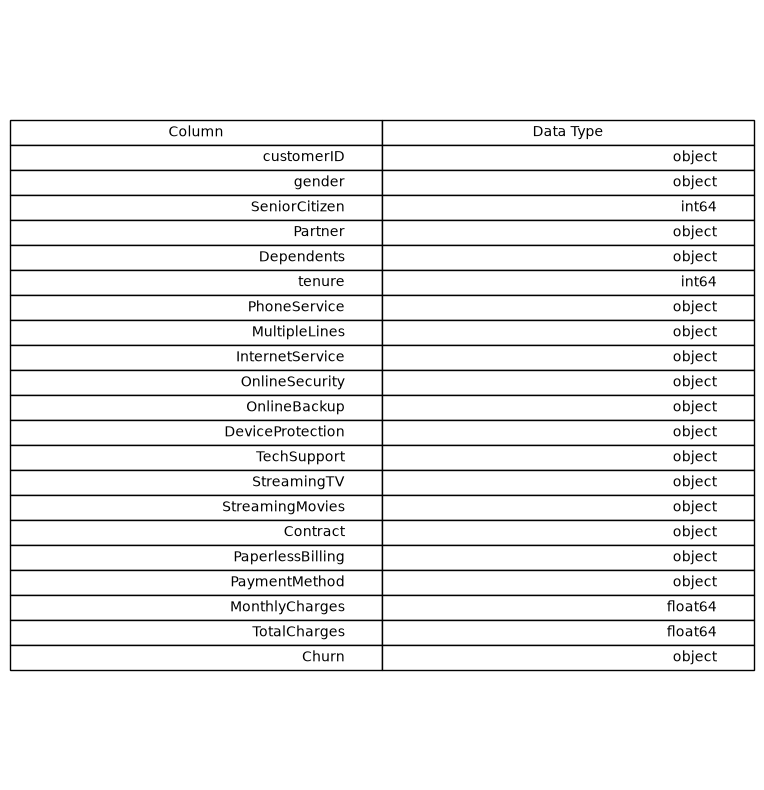

Screenshot saved successfully.


In [34]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 10))

ax.axis("off")

table = ax.table(
    cellText=data_types.reset_index().values,
    colLabels=["Column", "Data Type"],
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.savefig(
    "../screenshots/data_types_after_preprocessing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Screenshot saved successfully.")

## 7. Feature Encoding

Machine learning algorithms require numerical input. Therefore, categorical features are converted into numerical representations using One-Hot Encoding. This approach prevents introducing artificial ordering among categorical variables.

In [35]:
# ==========================================================
# Identify Categorical Columns
# ==========================================================

categorical_columns = df.select_dtypes(include=["object"]).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


In [36]:
# ==========================================================
# One-Hot Encoding
# ==========================================================

df_encoded = pd.get_dummies(
    df,
    drop_first=True,
    dtype=int
)

print("Encoding completed successfully.")

Encoding completed successfully.


In [37]:
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56.95,1889.50,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53.85,108.15,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,45,42.30,1840.75,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,1


In [38]:
print("Dataset Shape After Encoding:", df_encoded.shape)

Dataset Shape After Encoding: (7043, 7073)


In [39]:
# Save encoded dataset

df_encoded.to_csv(
    "../data/processed/customer_churn_encoded.csv",
    index=False
)

print("Encoded dataset saved successfully.")

Encoded dataset saved successfully.


In [41]:
# Display first five rows
print(df_encoded.head())

# Save first five rows as CSV
df_encoded.head().to_csv(
    "../reports/encoded_dataset_preview.csv",
    index=False
)

# Save first five rows as image
import matplotlib.pyplot as plt

preview = df_encoded.head()

fig, ax = plt.subplots(figsize=(16, 3))
ax.axis("off")

table = ax.table(
    cellText=preview.values,
    colLabels=preview.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(7)
table.scale(1.2, 1.5)

plt.savefig(
    "../screenshots/encoded_dataset_preview.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Encoded dataset preview saved successfully.")

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  customerID_0003-MKNFE  \
0              0       1           29.85         29.85                      0   
1              0      34           56.95       1889.50                      0   
2              0       2           53.85        108.15                      0   
3              0      45           42.30       1840.75                      0   
4              0       2           70.70        151.65                      0   

   customerID_0004-TLHLJ  customerID_0011-IGKFF  customerID_0013-EXCHZ  \
0                      0                      0                      0   
1                      0                      0                      0   
2                      0                      0                      0   
3                      0                      0                      0   
4                      0                      0                      0   

   customerID_0013-MHZWF  customerID_0013-SMEOE  ...  StreamingTV_Ye

In [42]:
shape_df = pd.DataFrame({
    "Rows": [df_encoded.shape[0]],
    "Columns": [df_encoded.shape[1]]
})

print(shape_df)

shape_df.to_csv(
    "../reports/dataset_shape_after_encoding.csv",
    index=False
)

fig, ax = plt.subplots(figsize=(4, 1.5))
ax.axis("off")

table = ax.table(
    cellText=shape_df.values,
    colLabels=shape_df.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

plt.savefig(
    "../screenshots/dataset_shape_after_encoding.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Dataset shape image saved successfully.")

   Rows  Columns
0  7043     7073
Dataset shape image saved successfully.


## 8. Feature Binning

Feature binning is performed to group continuous numerical values into meaningful categories.  
This supports Exploratory Data Analysis requirements such as binning and helps improve business interpretation of customer churn patterns.

Assignment Mapping: Sub-Objective 1.4 – EDA requires binning and analysis of features.

In [43]:
# %% 
# 8. Feature Binning

# Create a copy of encoded dataset for binning
df_binned = df_encoded.copy()

# Bin tenure into customer relationship stages
df_binned["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12 Months", "13-24 Months", "25-48 Months", "49-72 Months"],
    include_lowest=True
)

# Bin MonthlyCharges into spending categories
df_binned["monthly_charges_group"] = pd.cut(
    df["MonthlyCharges"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

# Bin TotalCharges into value categories
df_binned["total_charges_group"] = pd.cut(
    df["TotalCharges"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

print("Feature binning completed successfully.")

# Display binned feature preview
binning_preview = df_binned[
    ["tenure_group", "monthly_charges_group", "total_charges_group"]
].head(10)

binning_preview

Feature binning completed successfully.


,tenure_group,monthly_charges_group,total_charges_group
0,0-12 Months,Low,Low
1,25-48 Months,Medium,Low
2,0-12 Months,Medium,Low
3,25-48 Months,Low,Low
4,0-12 Months,Medium,Low
5,0-12 Months,High,Low
6,13-24 Months,High,Low
7,0-12 Months,Low,Low
8,25-48 Months,High,Medium
9,49-72 Months,Medium,Medium


In [44]:
# %%
# Save Feature Binning Preview

import os
import matplotlib.pyplot as plt

# Create folders if they do not exist
os.makedirs("../reports", exist_ok=True)

# Save preview as CSV
binning_preview.to_csv(
    "../reports/feature_binning_preview.csv",
    index=False
)

# Save preview as PNG
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis("off")

table = ax.table(
    cellText=binning_preview.values,
    colLabels=binning_preview.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)

plt.savefig(
    "../reports/feature_binning_preview.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Feature binning artifacts saved successfully.")
print("CSV : ../reports/feature_binning_preview.csv")
print("PNG : ../reports/feature_binning_preview.png")

Feature binning artifacts saved successfully.
CSV : ../reports/feature_binning_preview.csv
PNG : ../reports/feature_binning_preview.png


## 9. Feature Normalization

Feature normalization scales numerical features to a common range, improving the performance of many machine learning algorithms by preventing features with larger values from dominating those with smaller values.

Assignment Mapping: Sub-Objective 1.3 – Data Pre-processing (Normalization).

In [48]:

# 9. Feature Normalization

from sklearn.preprocessing import StandardScaler

# Create a copy of the encoded dataset
df_normalized = df_encoded.copy()

# Numerical columns to normalize
numerical_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

# Initialize scaler
scaler = StandardScaler()

# Normalize selected columns
df_normalized[numerical_columns] = scaler.fit_transform(
    df_normalized[numerical_columns]
)

print("Feature normalization completed successfully.")

# Preview normalized data
normalization_preview = df_normalized[numerical_columns].head(10)

normalization_preview

Feature normalization completed successfully.


,tenure,MonthlyCharges,TotalCharges
0,-1.277445,-1.160323,-0.994242
1,0.066327,-0.259629,-0.173244
2,-1.236724,-0.362660,-0.959674
3,0.514251,-0.746535,-0.194766
4,-1.236724,0.197365,-0.940470
5,-0.992402,1.159546,-0.645186
6,-0.422317,0.808907,-0.146799
7,-0.910961,-1.163647,-0.874137
8,-0.177995,1.330711,0.337349
9,1.206498,-0.286218,0.532439


In [53]:

# Save Feature Normalization Preview

import os
import matplotlib.pyplot as plt

# Recreate normalization preview safely
normalization_preview = df_normalized[numerical_columns].head(10)

# Create reports folder if it does not exist
os.makedirs("../reports", exist_ok=True)

# Save normalization preview as CSV
normalization_preview.to_csv(
    "../reports/feature_normalization_preview.csv",
    index=False
)

# Save normalization preview as PNG
fig, ax = plt.subplots(figsize=(7, 3))
ax.axis("off")

table = ax.table(
    cellText=normalization_preview.round(4).values,
    colLabels=normalization_preview.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)

plt.savefig(
    "../reports/feature_normalization_preview.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Feature normalization artifacts saved successfully.")
print("CSV : ../reports/feature_normalization_preview.csv")
print("PNG : ../reports/feature_normalization_preview.png")

Feature normalization artifacts saved successfully.
CSV : ../reports/feature_normalization_preview.csv
PNG : ../reports/feature_normalization_preview.png


## 10. Save Final Processed Dataset

The final processed dataset is saved after encoding and normalization. This dataset will be used for Exploratory Data Analysis, model training, evaluation, and API development.

Assignment Mapping: Sub-Objective 1.3 – Data Pre-processing.

In [50]:
import os

os.makedirs("../data/processed", exist_ok=True)

final_processed_path = "../data/processed/customer_churn_processed.csv"

df_normalized.to_csv(final_processed_path, index=False)

print("Final processed dataset saved successfully.")
print("Path:", final_processed_path)
print("Shape:", df_normalized.shape)

Final processed dataset saved successfully.
Path: ../data/processed/customer_churn_processed.csv
Shape: (7043, 7073)


In [51]:
import os
import matplotlib.pyplot as plt

os.makedirs("../reports", exist_ok=True)

processed_summary = pd.DataFrame({
    "Item": [
        "Final Processed Dataset Path",
        "Number of Rows",
        "Number of Columns",
        "Missing Values",
        "Duplicate Records"
    ],
    "Value": [
        "../data/processed/customer_churn_processed.csv",
        df_normalized.shape[0],
        df_normalized.shape[1],
        df_normalized.isnull().sum().sum(),
        df_normalized.duplicated().sum()
    ]
})

processed_summary.to_csv(
    "../reports/final_processed_dataset_summary.csv",
    index=False
)

fig, ax = plt.subplots(figsize=(9, 3))
ax.axis("off")

table = ax.table(
    cellText=processed_summary.values,
    colLabels=processed_summary.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)

plt.savefig(
    "../reports/final_processed_dataset_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Final processed dataset summary artifacts saved successfully.")
print("CSV : ../reports/final_processed_dataset_summary.csv")
print("PNG : ../reports/final_processed_dataset_summary.png")

processed_summary

Final processed dataset summary artifacts saved successfully.
CSV : ../reports/final_processed_dataset_summary.csv
PNG : ../reports/final_processed_dataset_summary.png


,Item,Value
0,Final Processed Dataset Path,../data/processed/customer_churn_processed.csv
1,Number of Rows,7043
2,Number of Columns,7073
3,Missing Values,0
4,Duplicate Records,0


## Conclusion

The data preprocessing phase has been successfully completed. The dataset was cleaned by handling duplicate records, converting data types, imputing missing values, encoding categorical variables, performing feature binning, and normalizing numerical features. The final processed dataset has been saved and is ready for Exploratory Data Analysis (EDA), machine learning model development, and API integration in the subsequent stages of the project.

Assignment Mapping:
- Sub-Objective 1.3 – Data Pre-processing
- Supports Sub-Objective 1.4 – Exploratory Data Analysis